<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
import joblib
from math import sqrt

Area under ROC score on Train dataset: 0.90%


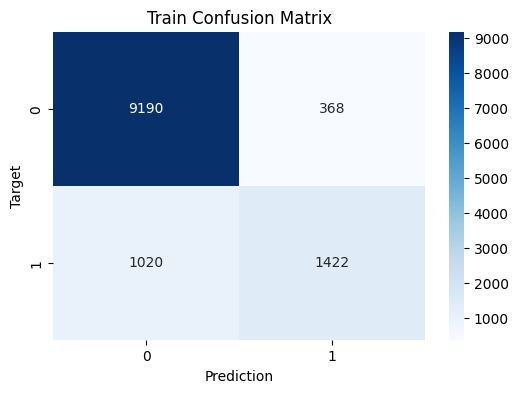


Classification Report for Train:

              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93      9558
         1.0       0.79      0.58      0.67      2442

    accuracy                           0.88     12000
   macro avg       0.85      0.77      0.80     12000
weighted avg       0.88      0.88      0.88     12000

Area under ROC score on Validation dataset: 0.88%


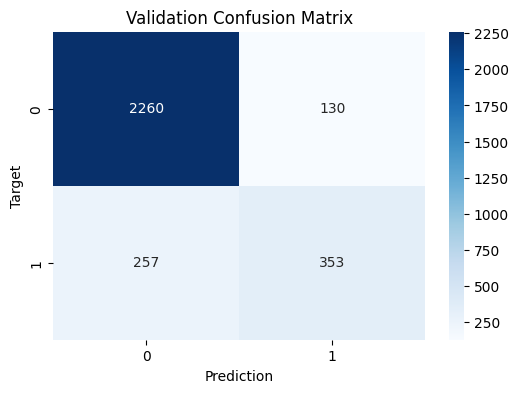


Classification Report for Validation:

              precision    recall  f1-score   support

         0.0       0.90      0.95      0.92      2390
         1.0       0.73      0.58      0.65       610

    accuracy                           0.87      3000
   macro avg       0.81      0.76      0.78      3000
weighted avg       0.86      0.87      0.87      3000



['bank_customer_churn_prediction.joblib']

In [3]:

raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/train.csv", index_col=0)
train_df, val_df = train_test_split(raw_df, test_size = 0.2, random_state = 42, stratify=raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df)[1: -1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    # Ймовірнісний прогноз за допомогою predict_proba для ROC curve
    probas = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, probas)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")

    # Побудуємо Confusion matrix
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues', fmt='g')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    # Побудуємо classification report для аналізу метрик
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(targets, preds))
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'bank_customer_churn_prediction.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train Poly2 dataset: 0.94%


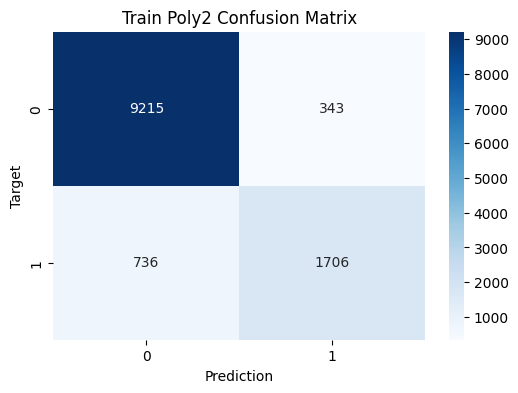


Classification Report for Train Poly2:

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94      9558
         1.0       0.83      0.70      0.76      2442

    accuracy                           0.91     12000
   macro avg       0.88      0.83      0.85     12000
weighted avg       0.91      0.91      0.91     12000

Area under ROC score on Val Poly2 dataset: 0.93%


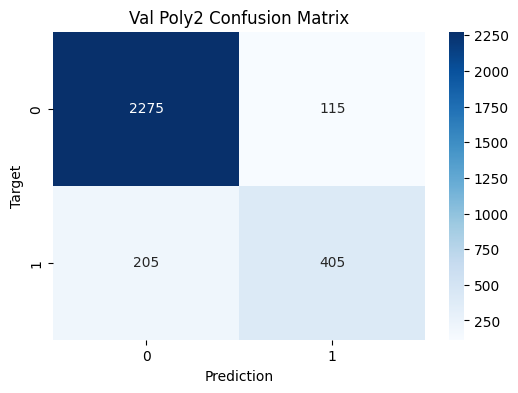


Classification Report for Val Poly2:

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93      2390
         1.0       0.78      0.66      0.72       610

    accuracy                           0.89      3000
   macro avg       0.85      0.81      0.83      3000
weighted avg       0.89      0.89      0.89      3000



In [4]:
import operator
from sklearn.preprocessing import PolynomialFeatures
# Створюємо пайплайн трансформер з піднесенням до степені 2
numeric_transformer_poly2 = Pipeline(steps = [
    ('poly', PolynomialFeatures(degree = 2, include_bias= False)),
    ('scaler', StandardScaler())
])
# Створюємо новий препроцесор
preprocessor_poly2 = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
# Створюємо новий пайплайн
model_pipeline_poly2 = Pipeline(steps = [
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver= 'liblinear', random_state= 42))
])
# Фітимо та тренеруємо пайплайн модель
model_pipeline_poly2.fit(train_inputs, train_targets)
# Запускаємо на тренувальних даних
train_preds_poly2 = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train Poly2')
# Запускаємо на валідаційних даних
val_preds_poly2 = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Val Poly2')

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train Poly4 dataset: 0.95%


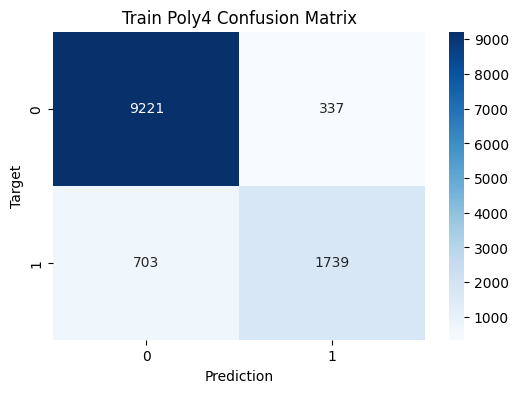


Classification Report for Train Poly4:

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.95      9558
         1.0       0.84      0.71      0.77      2442

    accuracy                           0.91     12000
   macro avg       0.88      0.84      0.86     12000
weighted avg       0.91      0.91      0.91     12000

Area under ROC score on Val Poly4 dataset: 0.93%


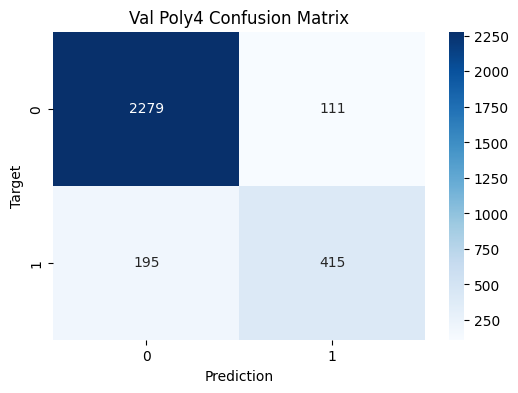


Classification Report for Val Poly4:

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      2390
         1.0       0.79      0.68      0.73       610

    accuracy                           0.90      3000
   macro avg       0.86      0.82      0.83      3000
weighted avg       0.89      0.90      0.90      3000



In [5]:
# Створюємо пайплайн трансформер з піднесенням до степені 4
numeric_transformer_poly4 = Pipeline(steps= [
    ('poly', PolynomialFeatures(degree = 4, include_bias = False)),
    ('scaler', StandardScaler())
])
# Створюємо новий препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)
# Створюємо новий пайплайн
model_pipeline_poly4 = Pipeline(steps =[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver = 'liblinear', random_state= 42))
])
# Фітимо та тренеруємо пайплайн модель
model_pipeline_poly4.fit(train_inputs, train_targets)
# Запускаємо на тренувальних даних
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train Poly4')
# Запускаємо на валідаційних даних
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Val Poly4')

In [13]:
import joblib
# Зберігаємо модель model_pipeline_poly4
joblib.dump(model_pipeline_poly4, 'bank_customer_churn_poly4_prediction.joblib')

['bank_customer_churn_poly4_prediction.joblib']

In [15]:
test_raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/test.csv")
test_inputs = test_raw_df[input_cols].copy()
# Передбачаємо
test_predictions = model_pipeline_poly4.predict(test_inputs)
test_raw_df['Exited'] = test_predictions.astype(int)

In [16]:
# Зчитуємо файл та заповнюємо передбаченнями
submission_df = pd.read_csv('/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/sample_submission.csv')
submission_df['Exited'] = test_raw_df['Exited']
display(submission_df.head())
submission_df.to_csv('submission_log_reg.csv', index=False)

,id,Exited
0,15000,0
1,15001,0
2,15002,0
3,15003,1
4,15004,0


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [6]:
reg_data_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/regression_data.csv")

In [ ]:
reg_data_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [7]:
# Розбиваємо на тренувальні та тестувальні набори
train_df, test_df = train_test_split(reg_data_df, test_size = 0.2, random_state = 42)

In [8]:
# Масштабуємо числові ознаки
scaler = MinMaxScaler()
numeric_cols_reg = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
# Трен набір
train_inputs_reg = train_df[numeric_cols_reg].copy()
train_targets_reg = train_df['target'].copy()
# Тест набір
test_inputs_reg = test_df[numeric_cols_reg].copy()
test_targets_reg = test_df['target'].copy()
# Фітимо
train_inputs_reg_scaled = scaler.fit_transform(train_inputs_reg)
test_inputs_reg_scaled = scaler.transform(test_inputs_reg)
# Оновлюємо df з масштабованими даними
train_inputs_reg[numeric_cols_reg] = train_inputs_reg_scaled
test_inputs_reg[numeric_cols_reg] = test_inputs_reg_scaled

In [9]:
# Створюємо трансформер для числових колонок з поліноміальними ознаками до степені 5
numeric_transformer_poly5 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler())
])
# Створюємо новий препроцесор
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly5, numeric_cols_reg)
    ])
# Створюємо пайплайн для лінійної регресії
model_pipeline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])
# Фітимо
model_pipeline_reg.fit(train_inputs_reg, train_targets_reg)
# Передбачаємо
train_preds_reg = model_pipeline_reg.predict(train_inputs_reg)
test_preds_reg = model_pipeline_reg.predict(test_inputs_reg)

train_r2 = r2_score(train_targets_reg, train_preds_reg)
train_MSE = mean_squared_error(train_targets_reg, train_preds_reg)
train_RMSE = sqrt(train_MSE)
test_r2 = r2_score(test_targets_reg, test_preds_reg)
test_MSE = mean_squared_error(test_targets_reg, test_preds_reg)
test_RMSE = sqrt(test_MSE)

print(f'Train df : R2 = {train_r2:.5f}, RMSE = {train_RMSE:.5f}')
print(f'Test df : R2 = {test_r2:.5f},  RMSE = {test_RMSE:.5f}')

Train df : R2 = 1.00000, RMSE = 0.00000
Test df : R2 = 0.85662,  RMSE = 18.28999


Висновок: R2 тренувального набору даних є більшим за тестувальний, та RMSE тренувального набору є дуже близьким до нуля. Можемо припустити що модель має оверфіт, тому не можемо сказати що модель добре генералізує

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [12]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
# Підносимо до 20го степеня
polynomial_features = PolynomialFeatures(degree=20, include_bias=False)
train_inputs_poly = polynomial_features.fit_transform(train_inputs_reg)
test_inputs_poly = polynomial_features.transform(test_inputs_reg)
# Масштабуємо числові ознаки
scaler = StandardScaler()
train_inputs_scaled = scaler.fit_transform(train_inputs_poly)
test_inputs_scaled = scaler.transform(test_inputs_poly)

# Список моделей для оцінки
models = [
    ("Linear Regression: ", LinearRegression()),
    ("Ridge: ", Ridge(alpha=1.0, random_state=42)),
    ("Lasso: ", Lasso(alpha=0.1, max_iter=10000, random_state=42)),
    ("ElasticNet: ", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42))
]

for name, model in models:
    print(name)
    # Фітимо
    model.fit(train_inputs_scaled, train_targets_reg)
    # Передбачаємо
    train_preds = model.predict(train_inputs_scaled)
    test_preds = model.predict(test_inputs_scaled)
    train_r2 = r2_score(train_targets_reg, train_preds)
    train_MSE = mean_squared_error(train_targets_reg, train_preds)
    train_RMSE = sqrt(train_MSE)

    test_r2 = r2_score(test_targets_reg, test_preds)
    test_MSE = mean_squared_error(test_targets_reg, test_preds)
    test_RMSE = sqrt(test_MSE)
    print(f'  Train df : R2 = {train_r2:.5f}, RMSE = {train_RMSE:.5f}')
    print(f'  Test df : R2 = {test_r2:.5f},  RMSE = {test_RMSE:.5f}\n')


Linear Regression: 
  Train df : R2 = 1.00000, RMSE = 0.00000
  Test df : R2 = 0.47278,  RMSE = 35.07199

Ridge: 
  Train df : R2 = 0.99956, RMSE = 0.92131
  Test df : R2 = 0.74645,  RMSE = 24.32167

Lasso: 
  Train df : R2 = 0.99943, RMSE = 1.05060
  Test df : R2 = 0.99966,  RMSE = 0.89323

ElasticNet: 
  Train df : R2 = 0.99607, RMSE = 2.76550
  Test df : R2 = 0.98754,  RMSE = 5.39220



Висновок: Порівнюючи показники R2 та RMSE моделей можна сказати що найкраще генералізує Ласо модель та Еластік, так як в них R2 є високим для тестових та тренувальних наборів даних. В інших моделей бачимо що R2 на тренувальних даних є більшим ніж у тестувальних, що є ознакою оверфіту